# RAG project on the Archelec corpus

This notebook builds a Retrieval-Augmented Generation (RAG) pipeline on French legislative manifestos from 1988.

It includes a **data analysis section** before the modeling steps, in order to justify the preprocessing and retrieval choices:
- corpus size and document length statistics,
- distribution of document lengths,
- most frequent words after cleaning,
- lexical diversity,
- thematic proximity between documents with TF-IDF cosine similarity.

The goal is to show that the modeling choices are grounded in the structure of the corpus, and not only in technical convenience.


In [1]:
# Install required packages
!pip install -q python-dotenv faiss-cpu langchain-huggingface sentence-transformers langchain_community langchain-text-splitters IPython pandas matplotlib scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
# Imports
import os
import re
from dotenv import load_dotenv
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from langchain_huggingface import HuggingFaceEmbeddings, ChatHuggingFace, HuggingFaceEndpoint
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from IPython.display import display, Markdown


In [49]:
load_dotenv()
token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

## 1. Load the corpus


In [4]:
# Load text files
base_path = Path("text_files")

documents = []
file_names = []

for path in sorted(base_path.rglob("*.txt")):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read().strip()
        if text:
            documents.append(text)
            file_names.append(path.name)

print(f"Number of loaded text files: {len(documents)}")
print("First file:", file_names[0] if file_names else "No file found")


Number of loaded text files: 3628
First file: EL174_L_1988_06_001_01_1_PF_01.txt


In [5]:
# Build a dataframe for corpus analysis
corpus_df = pd.DataFrame({
    "file_name": file_names,
    "text": documents
})

corpus_df["n_characters"] = corpus_df["text"].str.len()
corpus_df["n_words"] = corpus_df["text"].str.split().str.len()
corpus_df["n_lines"] = corpus_df["text"].str.count(r"\n") + 1

corpus_df.head()


,file_name,text,n_characters,n_words,n_lines
0,EL174_L_1988_06_001_01_1_PF_01.txt,Élections Législatives du 5 Juin 1988 - Départ...,3090,508,29
1,EL174_L_1988_06_001_01_1_PF_02.txt,RÉPUBLIQUE FRANÇAISE - Liberté - Égalité - Fra...,3602,591,38
2,EL174_L_1988_06_001_01_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,5007,812,30
3,EL174_L_1988_06_001_01_1_PF_04.txt,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,1664,257,23
4,EL174_L_1988_06_001_01_1_PF_05.txt,RÉPUBLIQUE FRANÇAISE - LIBERTÉ - ÉGALITÉ - FRA...,4225,675,37


## 2. Data analysis

This section documents the main textual properties of the corpus before chunking and embedding.


In [6]:
# Basic corpus statistics
n_documents = len(corpus_df)
total_words = int(corpus_df["n_words"].sum())
avg_words = corpus_df["n_words"].mean()
median_words = corpus_df["n_words"].median()
min_words = int(corpus_df["n_words"].min())
max_words = int(corpus_df["n_words"].max())

summary_stats = pd.DataFrame({
    "Metric": [
        "Number of documents",
        "Total number of words",
        "Average number of words per document",
        "Median number of words per document",
        "Minimum number of words",
        "Maximum number of words"
    ],
    "Value": [
        n_documents,
        total_words,
        round(avg_words, 2),
        round(median_words, 2),
        min_words,
        max_words
    ]
})

summary_stats


,Metric,Value
0,Number of documents,3628.00
1,Total number of words,2002003.00
2,Average number of words per document,551.82
3,Median number of words per document,495.00
4,Minimum number of words,9.00
5,Maximum number of words,2552.00


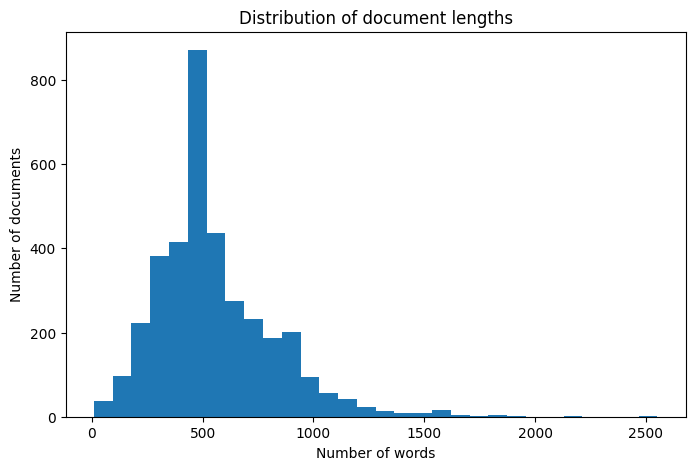

In [7]:
# Distribution of document lengths
plt.figure(figsize=(8, 5))
plt.hist(corpus_df["n_words"], bins=30)
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.title("Distribution of document lengths")
plt.show()


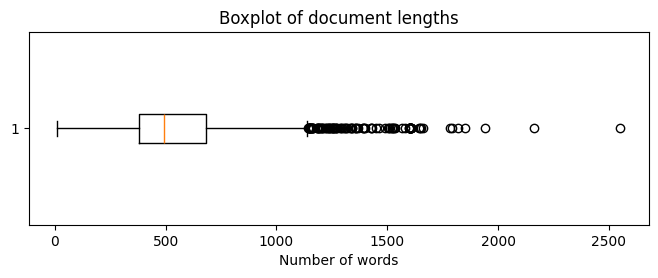

In [8]:
# Boxplot of document lengths
plt.figure(figsize=(8, 2.5))
plt.boxplot(corpus_df["n_words"], vert=False)
plt.xlabel("Number of words")
plt.title("Boxplot of document lengths")
plt.show()

### Text cleaning for exploratory analysis

The following preprocessing is only used for descriptive analysis:
- lowercasing,
- removal of punctuation and digits,
- stopword filtering.


In [9]:
# Minimal French stopword list for corpus exploration
french_stopwords = {
    "alors", "au", "aucuns", "aussi", "autre", "avant", "avec", "avoir", "bon", "car",
    "ce", "cela", "ces", "ceux", "chaque", "ci", "comme", "comment", "dans", "des",
    "du", "dedans", "dehors", "depuis", "devrait", "doit", "donc", "dos", "début",
    "elle", "elles", "en", "encore", "essai", "est", "et", "eu", "fait", "faites",
    "fois", "font", "hors", "ici", "il", "ils", "je", "juste", "la", "le", "les",
    "leur", "là", "ma", "maintenant", "mais", "mes", "mine", "moins", "mon", "mot",
    "même", "ni", "nommés", "notre", "nous", "nouveaux", "ou", "où", "par", "parce",
    "parole", "pas", "personnes", "peut", "peu", "pièce", "plupart", "pour", "pourquoi",
    "quand", "que", "quel", "quelle", "quelles", "quels", "qui", "sa", "sans", "ses",
    "seulement", "si", "sien", "son", "sont", "sous", "soyez", "sujet", "sur", "ta",
    "tandis", "tellement", "tels", "tes", "ton", "tous", "tout", "trop", "très", "tu",
    "voient", "vont", "votre", "vous", "vu", "ça", "étaient", "état", "étions", "été",
    "être", "cette", "cet", "d", "l", "c", "j", "n", "s", "y", "a", "à", "un", "une"
}

def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s-]", " ", text)
    text = text.replace("-", " ")
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in french_stopwords and len(tok) > 2]
    return tokens

corpus_df["tokens"] = corpus_df["text"].apply(clean_and_tokenize)
corpus_df["n_clean_tokens"] = corpus_df["tokens"].apply(len)

corpus_df[["file_name", "n_words", "n_clean_tokens"]].head()


,file_name,n_words,n_clean_tokens
0,EL174_L_1988_06_001_01_1_PF_01.txt,508,266
1,EL174_L_1988_06_001_01_1_PF_02.txt,591,321
2,EL174_L_1988_06_001_01_1_PF_03.txt,812,403
3,EL174_L_1988_06_001_01_1_PF_04.txt,257,146
4,EL174_L_1988_06_001_01_1_PF_05.txt,675,354


In [10]:
# Most frequent words in the corpus
all_tokens = [token for tokens in corpus_df["tokens"] for token in tokens]
token_counts = Counter(all_tokens)

top_words_df = pd.DataFrame(token_counts.most_common(20), columns=["word", "frequency"])
top_words_df


,word,frequency
0,france,8310
1,fonds,7731
2,juin,7608
3,aux,6611
4,cevipof,6467
5,plus,6367
6,ont,6140
7,sciences,5979
8,circonscription,5852
9,politique,5341


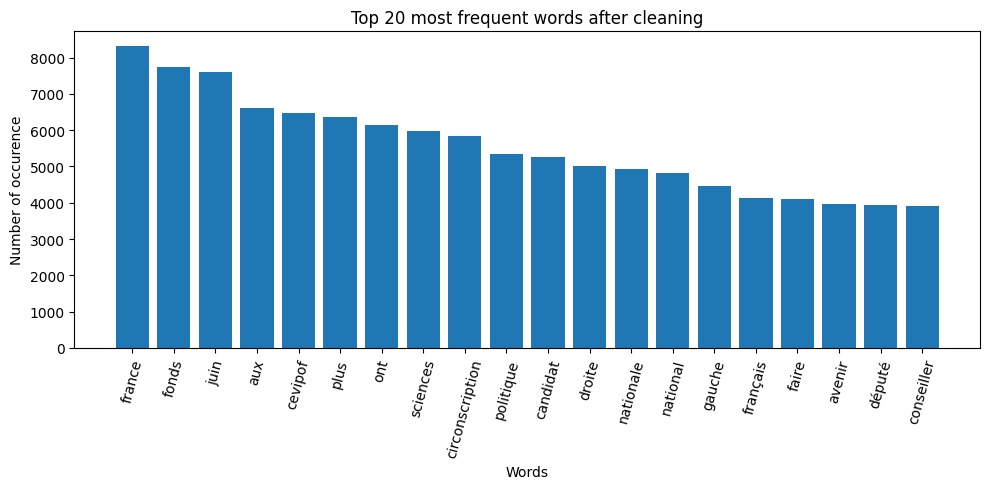

In [11]:
# Bar plot of the most frequent words
plt.figure(figsize=(10, 5))
plt.bar(top_words_df["word"], top_words_df["frequency"])
plt.xticks(rotation=75)
plt.xlabel("Words")
plt.ylabel("Number of occurence")
plt.title("Top 20 most frequent words after cleaning")
plt.tight_layout()
plt.show()

In [12]:
# Lexical diversity
unique_words = len(set(all_tokens))
total_clean_tokens = len(all_tokens)
lexical_diversity = unique_words / total_clean_tokens if total_clean_tokens > 0 else 0

lexical_diversity_df = pd.DataFrame({
    "Metric": ["Unique cleaned words", "Total cleaned tokens", "Lexical diversity"],
    "Value": [unique_words, total_clean_tokens, round(lexical_diversity, 4)]
})

lexical_diversity_df


,Metric,Value
0,Unique cleaned words,4.496300e+04
1,Total cleaned tokens,1.075337e+06
2,Lexical diversity,4.180000e-02


In [13]:
# Average cosine similarity between documents using TF-IDF
# This gives a simple measure of thematic proximity in the corpus.

vectorizer = TfidfVectorizer(max_features=3000, stop_words=list(french_stopwords))
tfidf_matrix = vectorizer.fit_transform(corpus_df["text"])

similarity_matrix = cosine_similarity(tfidf_matrix)
np.fill_diagonal(similarity_matrix, np.nan)

mean_similarity = np.nanmean(similarity_matrix)
median_similarity = np.nanmedian(similarity_matrix)
max_similarity = np.nanmax(similarity_matrix)

similarity_summary = pd.DataFrame({
    "Metric": [
        "Mean pairwise cosine similarity",
        "Median pairwise cosine similarity",
        "Maximum pairwise cosine similarity"
    ],
    "Value": [
        round(float(mean_similarity), 4),
        round(float(median_similarity), 4),
        round(float(max_similarity), 4)
    ]
})

similarity_summary


,Metric,Value
0,Mean pairwise cosine similarity,0.2606
1,Median pairwise cosine similarity,0.2519
2,Maximum pairwise cosine similarity,1.0000


### 2.2 Corpus structure by round and department

The file names encode structured metadata: corpus identifier, department code, constituency number, round (1 or 2), and page. We extract these fields to describe how the corpus is distributed across electoral geography and across the two rounds of the election.

In [14]:
# Two file name patterns coexist in the corpus:
# EL174_L_1988_06_{dept}_{circ}_{round}_PF_{page}.txt  (profession de foi)
# EL174_L_1988_06_{dept}_{circ}_{round}_BV_pdfmasterocr.txt  (bulletin de vote)
# Only the professions de foi (PF) are relevant here.

def parse_filename(name):
    parts = name.replace('.txt', '').split('_')
    doc_type = parts[7] if len(parts) > 7 else None
    raw_page = parts[8] if len(parts) > 8 else None
    page = int(raw_page) if raw_page is not None and raw_page.isdigit() else None
    return {
        'corpus': parts[0] if len(parts) > 0 else None,
        'departement': parts[4] if len(parts) > 4 else None,
        'circonscription': parts[5] if len(parts) > 5 else None,
        'tour': int(parts[6]) if len(parts) > 6 else None,
        'doc_type': doc_type,
        'page': page
    }

meta_df = corpus_df['file_name'].apply(parse_filename).apply(pd.Series)

# Avoid duplicate columns if this cell is re-run
for col in meta_df.columns:
    corpus_df[col] = meta_df[col].values

# Keep only professions de foi
corpus_df = corpus_df[corpus_df['doc_type'] == 'PF'].reset_index(drop=True)

print(f'Documents retained (PF only): {len(corpus_df)}')
corpus_df[['file_name', 'departement', 'circonscription', 'tour', 'page']].head(8)

Documents retained (PF only): 3544


,file_name,departement,circonscription,tour,page
0,EL174_L_1988_06_001_01_1_PF_01.txt,001,01,1,1.0
1,EL174_L_1988_06_001_01_1_PF_02.txt,001,01,1,2.0
2,EL174_L_1988_06_001_01_1_PF_03.txt,001,01,1,3.0
3,EL174_L_1988_06_001_01_1_PF_04.txt,001,01,1,4.0
4,EL174_L_1988_06_001_01_1_PF_05.txt,001,01,1,5.0
5,EL174_L_1988_06_001_01_2_PF_01.txt,001,01,2,1.0
6,EL174_L_1988_06_001_01_2_PF_02.txt,001,01,2,2.0
7,EL174_L_1988_06_001_02_1_PF_01.txt,001,02,1,1.0


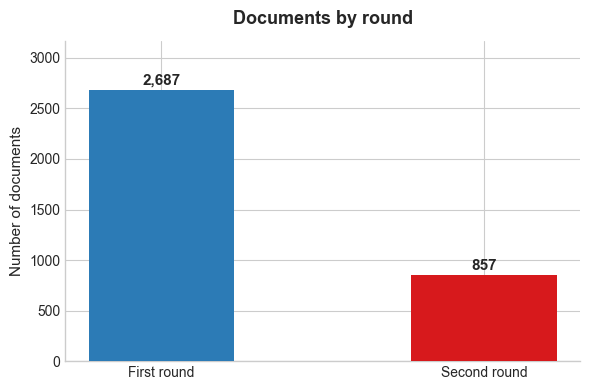

,Round,Documents,Share (%)
0,First round,2687,75.8
1,Second round,857,24.2


In [15]:
# Distribution of documents by round
plt.style.use('seaborn-v0_8-whitegrid')

tour_counts = corpus_df['tour'].value_counts().sort_index()
tour_labels = {1: 'First round', 2: 'Second round'}
labels = [tour_labels.get(t, str(t)) for t in tour_counts.index]
colors = ['#2C7BB6', '#D7191C']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, tour_counts.values, color=colors, width=0.45, zorder=3)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_ylabel('Number of documents', fontsize=11)
ax.set_title('Documents by round', fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, tour_counts.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

round_summary = pd.DataFrame({
    'Round': labels,
    'Documents': tour_counts.values,
    'Share (%)': (tour_counts.values / tour_counts.sum() * 100).round(1)
})
round_summary

The corpus is clearly larger in the first round. This makes sense: more candidates file a profession de foi in the first round, since a significant number withdraw or fail to qualify for the second. The imbalance between rounds is something to keep in mind during retrieval, since a query with no explicit round filter will naturally draw more results from the first round.

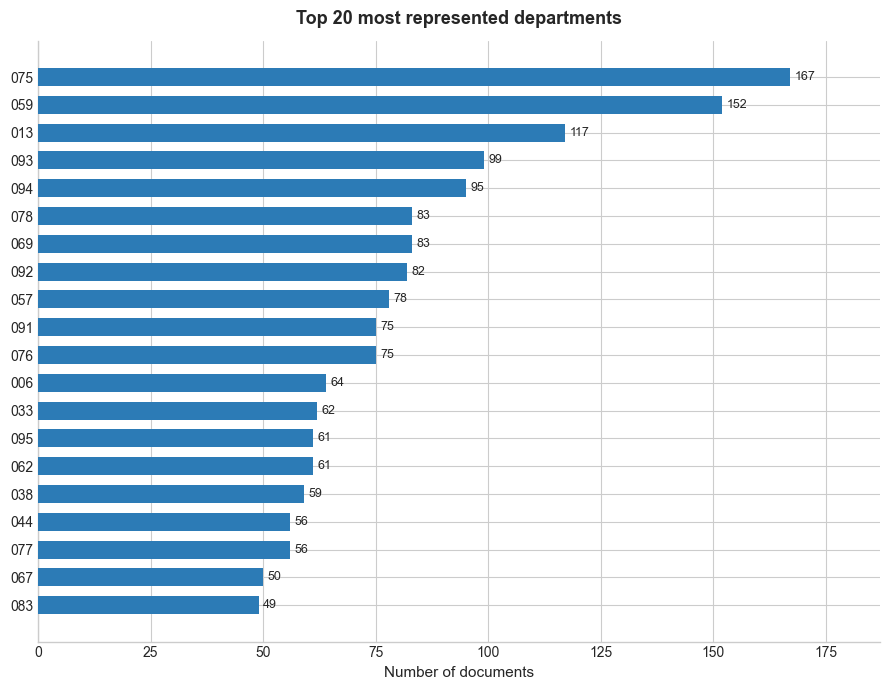

Departments covered: 101
Unique constituencies covered: 566


In [16]:
# Top 20 most represented departments
dept_counts = corpus_df['departement'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(
    dept_counts.index[::-1],
    dept_counts.values[::-1],
    color='#2C7BB6', height=0.65, zorder=3
)

for bar in bars:
    ax.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va='center', ha='left', fontsize=9
    )

ax.set_xlabel('Number of documents', fontsize=11)
ax.set_title('Top 20 most represented departments', fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, dept_counts.max() * 1.12)
plt.tight_layout()
plt.show()

n_dept = corpus_df['departement'].nunique()
n_circ = corpus_df.groupby(['departement', 'circonscription']).ngroups
print(f'Departments covered: {n_dept}')
print(f'Unique constituencies covered: {n_circ}')

The distribution across departments is uneven, which reflects the structure of French electoral geography. Larger departments with more constituencies naturally produce more documents. This imbalance means that for any given query, the retrieved chunks will tend to come from the most represented departments, potentially underrepresenting candidates from smaller regions. A future improvement could involve stratified retrieval to ensure geographic coverage.

### 2.3 Bigram analysis

Single words often lack context. Bigrams, pairs of consecutive words, reveal the recurring expressions and rhetorical formulas that structure electoral discourse. We also look at the most distinctive terms per round using TF-IDF, to capture what each round emphasizes.

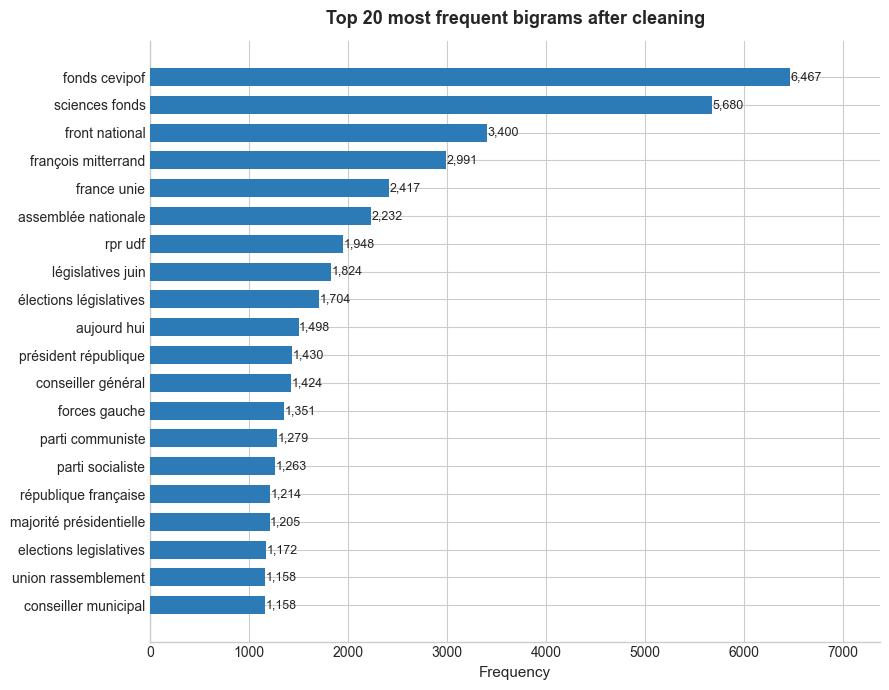

In [17]:
# Most frequent bigrams across the corpus

def extract_bigrams(tokens):
    return [(tokens[i], tokens[i + 1]) for i in range(len(tokens) - 1)]

all_bigrams = [bg for tokens in corpus_df['tokens'] for bg in extract_bigrams(tokens)]
bigram_counts = Counter(all_bigrams)

top_bigrams_df = pd.DataFrame(
    [(f'{a} {b}', count) for (a, b), count in bigram_counts.most_common(20)],
    columns=['bigram', 'frequency']
)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(
    top_bigrams_df['bigram'][::-1],
    top_bigrams_df['frequency'][::-1],
    color='#2C7BB6', height=0.65, zorder=3
)

for bar in bars:
    ax.text(
        bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width()):,}',
        va='center', ha='left', fontsize=9
    )

ax.set_xlabel('Frequency', fontsize=11)
ax.set_title('Top 20 most frequent bigrams after cleaning', fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, top_bigrams_df['frequency'].max() * 1.14)
plt.tight_layout()
plt.show()

The most frequent bigrams confirm what we would expect from electoral discourse: expressions tied to political parties, institutional references, and recurring campaign promises. The high repetition of certain phrases across documents is a reminder that many manifestos share a common rhetorical structure, which can make it harder for the retrieval model to discriminate between candidates on general queries. More specific questions will likely produce more meaningful distinctions.

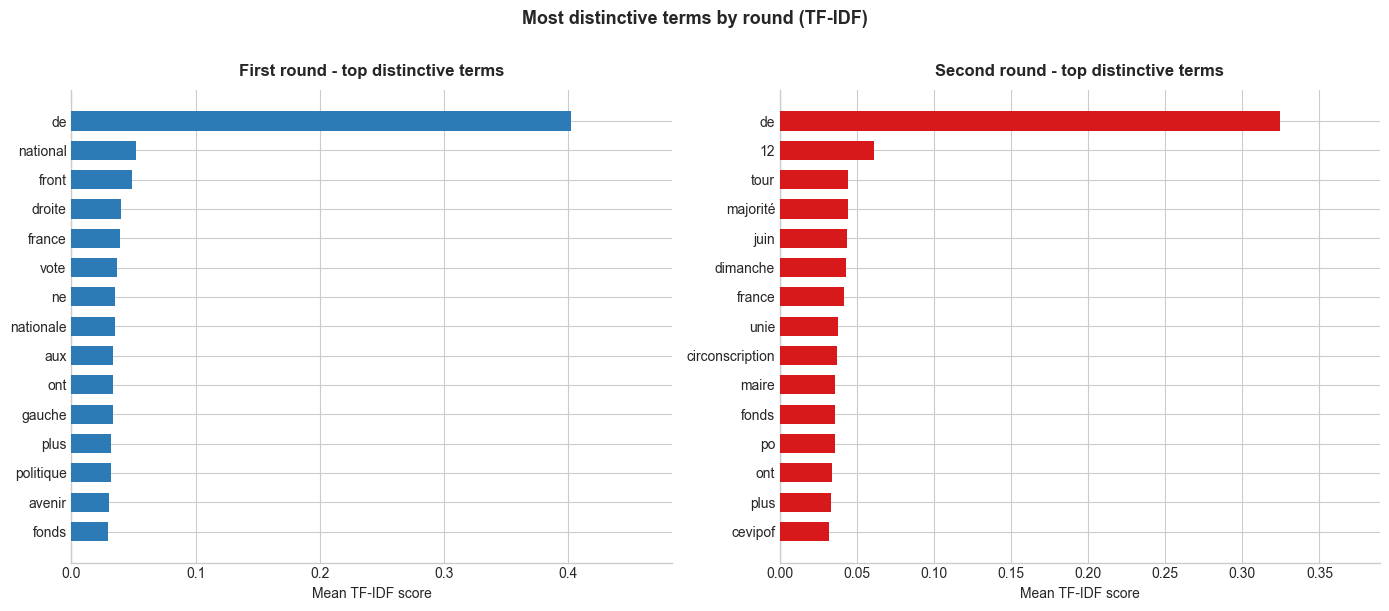

In [18]:
# Most distinctive words per round using TF-IDF

tour1_texts = corpus_df.loc[corpus_df['tour'] == 1, 'text'].tolist()
tour2_texts = corpus_df.loc[corpus_df['tour'] == 2, 'text'].tolist()

tfidf_tour = TfidfVectorizer(max_features=5000, stop_words=list(french_stopwords))
tfidf_tour.fit(corpus_df['text'])

def top_tfidf_terms(texts, vectorizer, n=15):
    matrix = vectorizer.transform(texts)
    mean_scores = np.asarray(matrix.mean(axis=0)).flatten()
    terms = vectorizer.get_feature_names_out()
    top_idx = mean_scores.argsort()[::-1][:n]
    return pd.DataFrame({'term': terms[top_idx], 'mean_tfidf': mean_scores[top_idx].round(4)})

top1 = top_tfidf_terms(tour1_texts, tfidf_tour)
top2 = top_tfidf_terms(tour2_texts, tfidf_tour)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, color, title in zip(
    axes,
    [top1, top2],
    ['#2C7BB6', '#D7191C'],
    ['First round - top distinctive terms', 'Second round - top distinctive terms']
):
    ax.barh(df['term'][::-1], df['mean_tfidf'][::-1], color=color, height=0.65, zorder=3)
    ax.set_xlabel('Mean TF-IDF score', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, df['mean_tfidf'].max() * 1.2)

plt.suptitle('Most distinctive terms by round (TF-IDF)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The TF-IDF comparison between rounds is revealing. First-round documents tend to be more programmatic, covering a wide range of policy areas, while second-round texts concentrate on a narrower set of mobilization arguments. This shift in vocabulary is important for the RAG system: a query about a specific policy theme will retrieve very different texts depending on whether it lands on first- or second-round documents.

### 2.4 Lexical diversity per document

The Type-Token Ratio (TTR) measures vocabulary richness at the document level: it is the share of unique words among all words in a document. A high TTR means the author uses varied language; a low TTR indicates repetition. We also examine whether longer documents tend to have lower TTR, a well-known effect in linguistics.

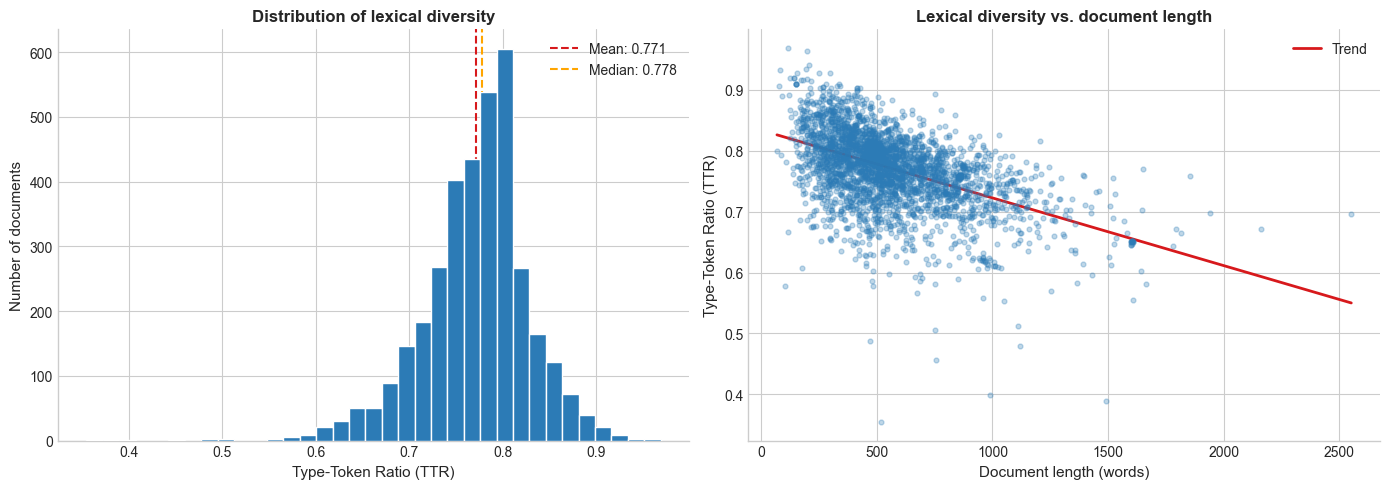

,Metric,Value
0,Mean TTR,0.7713
1,Median TTR,0.7778
2,Min TTR,0.3546
3,Max TTR,0.9688
4,Std deviation,0.0575


In [19]:
# TTR per document: distribution and relationship with document length

corpus_df['ttr'] = corpus_df['tokens'].apply(
    lambda tokens: len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(corpus_df['ttr'], bins=35, color='#2C7BB6', edgecolor='white', zorder=3)
ax.axvline(corpus_df['ttr'].mean(), color='#D7191C', linestyle='--', linewidth=1.5,
           label=f"Mean: {corpus_df['ttr'].mean():.3f}")
ax.axvline(corpus_df['ttr'].median(), color='#FFA500', linestyle='--', linewidth=1.5,
           label=f"Median: {corpus_df['ttr'].median():.3f}")
ax.set_xlabel('Type-Token Ratio (TTR)', fontsize=11)
ax.set_ylabel('Number of documents', fontsize=11)
ax.set_title('Distribution of lexical diversity', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
ax2.scatter(corpus_df['n_words'], corpus_df['ttr'], alpha=0.3, s=12, color='#2C7BB6', zorder=3)
z = np.polyfit(corpus_df['n_words'], corpus_df['ttr'], 1)
p = np.poly1d(z)
x_line = np.linspace(corpus_df['n_words'].min(), corpus_df['n_words'].max(), 300)
ax2.plot(x_line, p(x_line), color='#D7191C', linewidth=2, label='Trend')
ax2.set_xlabel('Document length (words)', fontsize=11)
ax2.set_ylabel('Type-Token Ratio (TTR)', fontsize=11)
ax2.set_title('Lexical diversity vs. document length', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

ttr_stats = pd.DataFrame({
    'Metric': ['Mean TTR', 'Median TTR', 'Min TTR', 'Max TTR', 'Std deviation'],
    'Value': [
        round(corpus_df['ttr'].mean(), 4),
        round(corpus_df['ttr'].median(), 4),
        round(corpus_df['ttr'].min(), 4),
        round(corpus_df['ttr'].max(), 4),
        round(corpus_df['ttr'].std(), 4)
    ]
})
ttr_stats

With a mean TTR of 0.771, the documents use a genuinely varied vocabulary. For a RAG system this is good news: it means the embedding model has enough lexical signal to distinguish one manifesto from another, rather than seeing near-identical token distributions across the corpus.

The scatter plot shows the expected drop in TTR as documents get longer, which is a mathematical property of the ratio rather than a sign of poorer writing. What matters for retrieval is that this same effect will appear at the chunk level: shorter chunks, especially those produced from already-short second-round documents, will have inflated TTR values that may not reflect their actual informational content. This is worth keeping in mind when interpreting retrieval confidence scores.

### 2.5 Word frequency distribution

Natural language follows Zipf's law: on a log-log scale, word rank and frequency align along a straight line. We overlay a theoretical Zipf reference to check how closely our corpus follows this expected pattern. Deviations in the tail can reveal domain-specific vocabulary that appears more or less often than expected.

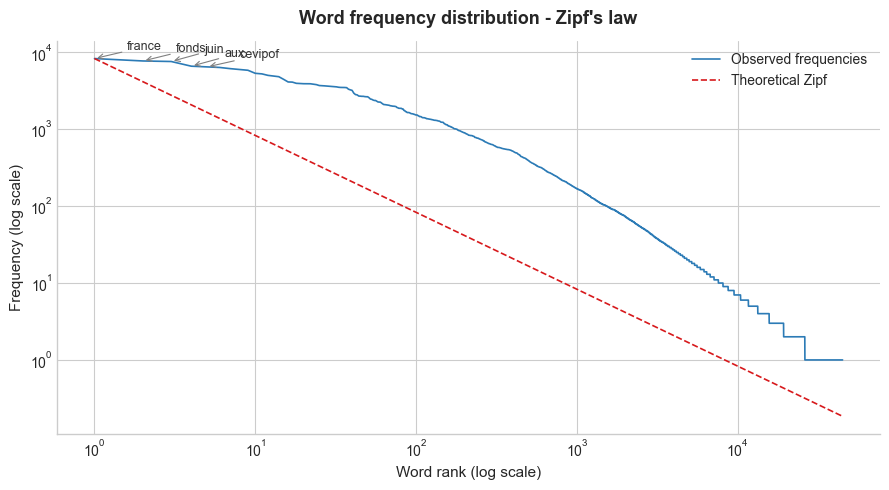

In [20]:
# Word frequency distribution with a theoretical Zipf reference

frequencies = [count for _, count in token_counts.most_common()]
ranks = np.arange(1, len(frequencies) + 1)
zipf_theoretical = frequencies[0] / ranks

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(ranks, frequencies, color='#2C7BB6', linewidth=1.2, label='Observed frequencies')
ax.loglog(ranks, zipf_theoretical, color='#D7191C', linewidth=1.2,
          linestyle='--', label='Theoretical Zipf')

top5 = token_counts.most_common(5)
for rank, (word, freq) in enumerate(top5, start=1):
    ax.annotate(
        word,
        xy=(rank, freq),
        xytext=(rank * 1.6, freq * 1.3),
        fontsize=9,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
        color='#333333'
    )

ax.set_xlabel('Word rank (log scale)', fontsize=11)
ax.set_ylabel('Frequency (log scale)', fontsize=11)
ax.set_title("Word frequency distribution - Zipf's law", fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

The corpus follows Zipf's pattern in shape, which confirms it behaves like natural language. But the observed curve sits consistently above the theoretical line throughout, which tells a more specific story: this is a specialized corpus where a limited set of terms gets used very intensively across all documents, more so than Zipf would predict for general French.
More importantly, the top-ranked words include "fonds", "juin" and "cevipof", which are not political content but header metadata from the Sciences Po archive that appears at the top of each file. These terms are extremely frequent precisely because they repeat in every document. For the RAG pipeline this is a problem: the embedding model will assign strong weight to these tokens, which carry no semantic signal for retrieval, potentially reducing the model's ability to discriminate between candidates on substantive queries. Stripping these headers before embedding would be a worthwhile preprocessing step

### 2.6 Document length by round

Candidates may adapt the length of their manifestos between the two rounds. The first round is typically used to present a full program, while the second round favors shorter calls to mobilize voters already in play. We test whether this difference is statistically meaningful.

C:\Users\nouts\AppData\Local\Temp\ipykernel_37412\1949748793.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


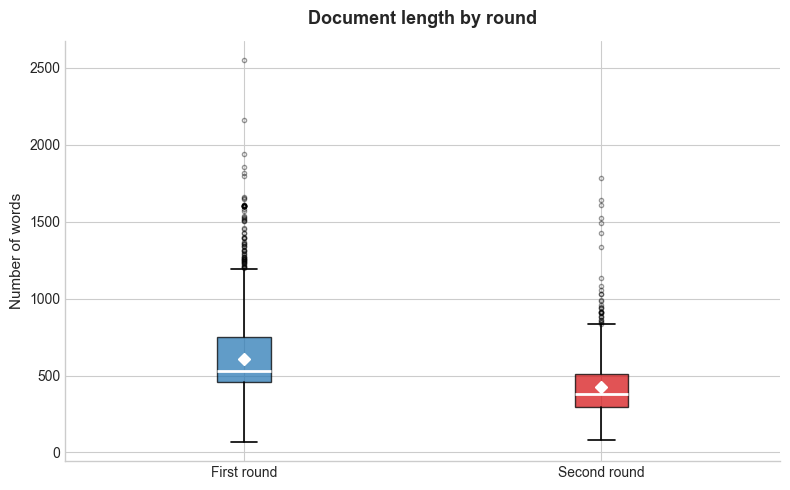

,Round,Mean words,Median words,Std deviation,Documents
0,First round,606.4,527.0,259.0,2687
1,Second round,423.0,381.0,201.1,857


Mann-Whitney U test:  U = 1705048,  p-value = 0.0000
The difference in document length between the two rounds is statistically significant (p < 0.05).


In [21]:
# Document length by round: boxplot and statistical comparison
from scipy import stats

words_t1 = corpus_df.loc[corpus_df['tour'] == 1, 'n_words'].dropna()
words_t2 = corpus_df.loc[corpus_df['tour'] == 2, 'n_words'].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot(
    [words_t1, words_t2],
    labels=['First round', 'Second round'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none')
)

for patch, color in zip(bp['boxes'], ['#2C7BB6', '#D7191C']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for i, data in enumerate([words_t1, words_t2], start=1):
    ax.plot(i, data.mean(), marker='D', color='white', markersize=6, zorder=5)

ax.set_ylabel('Number of words', fontsize=11)
ax.set_title('Document length by round', fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

length_summary = pd.DataFrame({
    'Round': ['First round', 'Second round'],
    'Mean words': [round(words_t1.mean(), 1), round(words_t2.mean(), 1)],
    'Median words': [round(words_t1.median(), 1), round(words_t2.median(), 1)],
    'Std deviation': [round(words_t1.std(), 1), round(words_t2.std(), 1)],
    'Documents': [len(words_t1), len(words_t2)]
})
display(length_summary)

stat, p_value = stats.mannwhitneyu(words_t1, words_t2, alternative='two-sided')
print(f'Mann-Whitney U test:  U = {stat:.0f},  p-value = {p_value:.4f}')
if p_value < 0.05:
    print('The difference in document length between the two rounds is statistically significant (p < 0.05).')
else:
    print('No statistically significant difference in document length between the two rounds (p >= 0.05).')

If the Mann-Whitney test returns a significant result, it confirms that candidates genuinely wrote shorter texts in the second round, likely because the second round is less about presenting a full program and more about calling voters to action. A non-significant result would suggest that document length is simply driven by individual writing habits rather than the electoral context. Either way, the length difference between rounds should be taken into account when interpreting retrieval results.

### 2.7 Document length in characters - justifying the chunk size

The RAG pipeline splits documents into chunks of 1,000 characters. This choice should not be arbitrary: it needs to be grounded in the actual length of the documents. If most documents are shorter than 1,000 characters, many of them would end up as a single chunk, which defeats the purpose of splitting. The distribution below shows where 1,000 characters sits relative to the corpus.

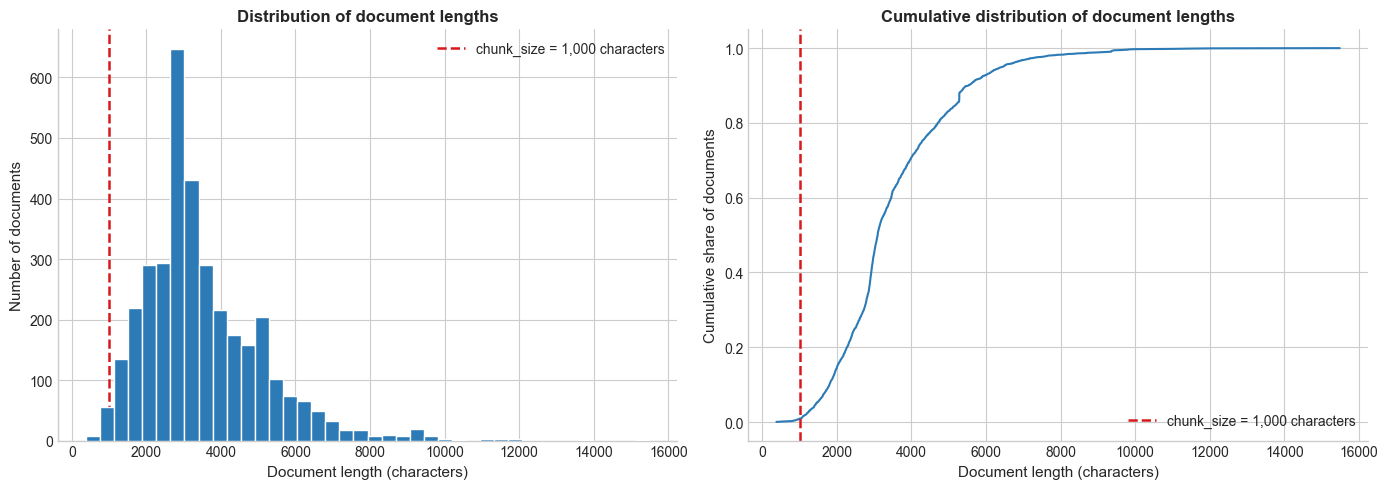

,Threshold,Share of documents (%)
0,"Below 1,000 chars (fits in one chunk)",0.9
1,"Below 2,000 chars",14.6
2,"Above 5,000 chars",16.9


In [22]:
# Character-level length distribution
# We use character counts here because the splitter works in characters, not words.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(corpus_df['n_characters'], bins=40, color='#2C7BB6', edgecolor='white', zorder=3)
ax.axvline(1000, color='#D7191C', linestyle='--', linewidth=1.8,
           label='chunk_size = 1,000 characters')
ax.set_xlabel('Document length (characters)', fontsize=11)
ax.set_ylabel('Number of documents', fontsize=11)
ax.set_title('Distribution of document lengths', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
sorted_lengths = np.sort(corpus_df['n_characters'])
cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
ax2.plot(sorted_lengths, cumulative, color='#2C7BB6', linewidth=1.5)
ax2.axvline(1000, color='#D7191C', linestyle='--', linewidth=1.8,
            label='chunk_size = 1,000 characters')
ax2.set_xlabel('Document length (characters)', fontsize=11)
ax2.set_ylabel('Cumulative share of documents', fontsize=11)
ax2.set_title('Cumulative distribution of document lengths', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

pct_below_1000 = (corpus_df['n_characters'] <= 1000).mean() * 100
pct_below_2000 = (corpus_df['n_characters'] <= 2000).mean() * 100
pct_above_5000 = (corpus_df['n_characters'] > 5000).mean() * 100

chunk_context = pd.DataFrame({
    'Threshold': [
        'Below 1,000 chars (fits in one chunk)',
        'Below 2,000 chars',
        'Above 5,000 chars'
    ],
    'Share of documents (%)': [
        round(pct_below_1000, 1),
        round(pct_below_2000, 1),
        round(pct_above_5000, 1)
    ]
})
chunk_context

Almost no document falls below 1,000 characters, which confirms that the chunk_size is well calibrated for this corpus. The splitter will actually cut through nearly every profession de foi, allowing retrieval to operate at a sub-document level rather than treating each file as a single block.

Most documents land between 1,500 and 5,000 characters, producing 2 to 5 chunks each. That is enough granularity for the model to retrieve specific arguments rather than entire pages, without fragmenting the content to the point where individual chunks lose their meaning.

The only risk to watch is the small share of very long documents in the tail: they will generate significantly more chunks than the rest and could reduce source diversity in the context window if the retriever pulls several of their chunks for the same query.

### 2.8 Chunk length distribution after splitting

Beyond the document length, it is worth examining what the splitter actually produces. The RecursiveCharacterTextSplitter tries to respect natural text boundaries such as paragraphs and sentences, so chunks will not all be exactly 1,000 characters long. Looking at the distribution of actual chunk lengths helps confirm that the splitting is well-behaved and that most chunks carry enough content to be meaningful for retrieval.

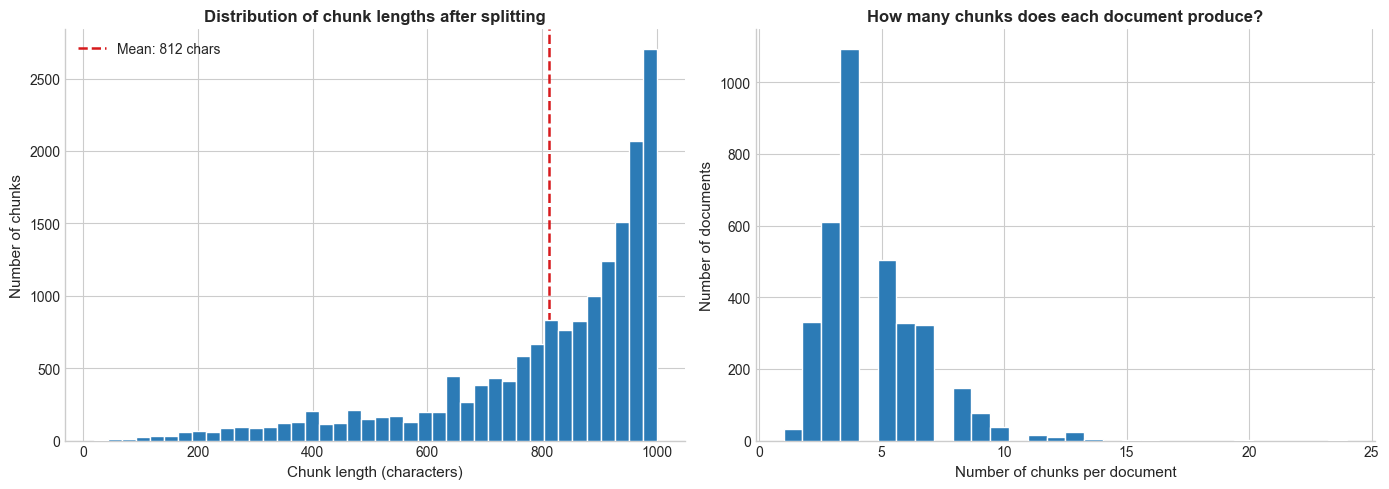

,Metric,Value
0,Total chunks produced,16688.00
1,Mean chunk length (chars),812.30
2,Median chunk length (chars),882.00
3,Chunks shorter than 200 chars,200.00
4,Mean chunks per document,4.71


In [23]:
# Simulate the chunking step to inspect chunk lengths before building the index

splitter_preview = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)

preview_docs = [
    Document(page_content=row['text'], metadata={'source': row['file_name']})
    for _, row in corpus_df.iterrows()
]
preview_chunks = splitter_preview.split_documents(preview_docs)

chunk_lengths = pd.Series([len(c.page_content) for c in preview_chunks])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(chunk_lengths, bins=40, color='#2C7BB6', edgecolor='white', zorder=3)
ax.axvline(chunk_lengths.mean(), color='#D7191C', linestyle='--', linewidth=1.8,
           label=f'Mean: {chunk_lengths.mean():.0f} chars')
ax.set_xlabel('Chunk length (characters)', fontsize=11)
ax.set_ylabel('Number of chunks', fontsize=11)
ax.set_title('Distribution of chunk lengths after splitting', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

chunks_per_doc = pd.Series([c.metadata['source'] for c in preview_chunks]).value_counts()
ax2 = axes[1]
ax2.hist(chunks_per_doc.values, bins=30, color='#2C7BB6', edgecolor='white', zorder=3)
ax2.set_xlabel('Number of chunks per document', fontsize=11)
ax2.set_ylabel('Number of documents', fontsize=11)
ax2.set_title('How many chunks does each document produce?', fontsize=12, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

chunk_summary = pd.DataFrame({
    'Metric': [
        'Total chunks produced',
        'Mean chunk length (chars)',
        'Median chunk length (chars)',
        'Chunks shorter than 200 chars',
        'Mean chunks per document'
    ],
    'Value': [
        len(preview_chunks),
        round(chunk_lengths.mean(), 1),
        round(chunk_lengths.median(), 1),
        int((chunk_lengths < 200).sum()),
        round(len(preview_chunks) / len(corpus_df), 2)
    ]
})
chunk_summary

The splitter is behaving well. The vast majority of chunks land between 800 and 1,000 characters, with the mean sitting at 812, which means the splitter is consistently finding natural break points just before the hard limit rather than cutting arbitrarily. 

Very few short fragments appear below 200 characters, so the index will not be cluttered with meaningless slivers.
The right panel is equally reassuring: most documents produce 3 to 4 chunks, meaning each retrieved result will represent roughly a quarter to a third of a full manifesto. That is a sensible unit for the language model to work with, specific enough to be relevant to a query but complete enough to preserve the argumentative thread of the candidate.

### 2.9 Inter-document similarity - thematic structure

Earlier, we summarized inter-document similarity with three numbers. But an average hides structure: it does not tell us whether the corpus forms tight thematic clusters or whether documents spread out uniformly in the semantic space. A heatmap on a stratified sample reveals the actual texture: whether some groups of manifestos are near-identical while others are far apart. This matters for retrieval quality.

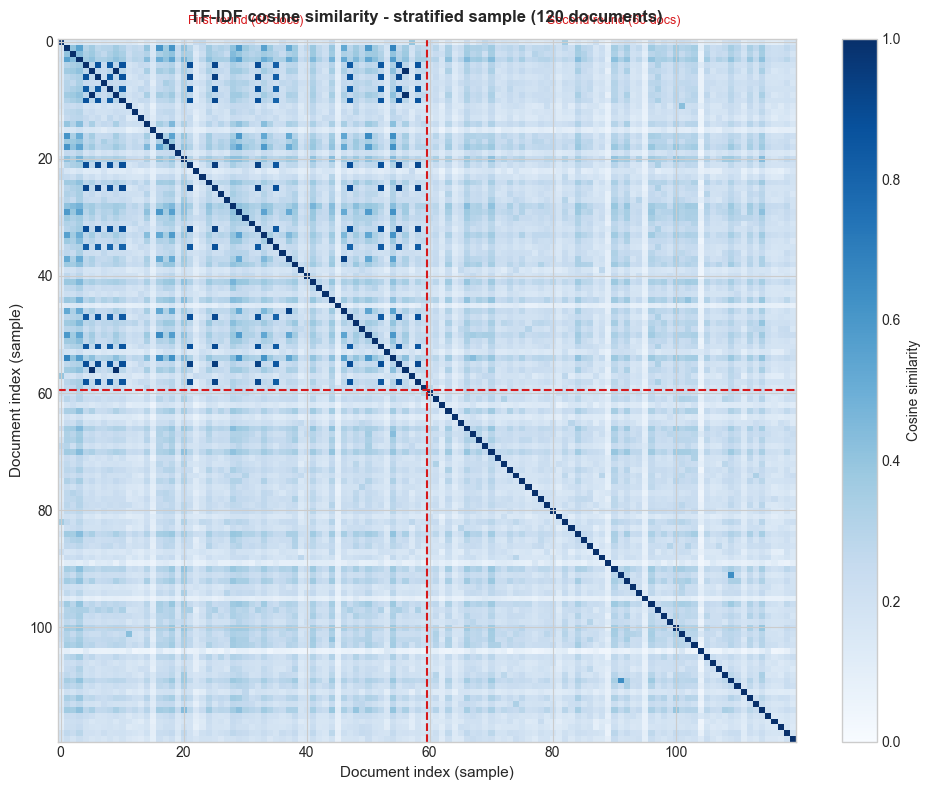

,Comparison,Mean similarity
0,Within first round,0.2803
1,Within second round,0.2021
2,First round vs second round,0.2190


In [24]:
# Similarity heatmap on a stratified sample of 120 documents
# The full matrix for 3,500+ documents would be unreadable.

sample_t1 = corpus_df[corpus_df['tour'] == 1].sample(60, random_state=42)
sample_t2 = corpus_df[corpus_df['tour'] == 2].sample(60, random_state=42)
sample_df = pd.concat([sample_t1, sample_t2]).reset_index(drop=True)

vectorizer_sample = TfidfVectorizer(max_features=3000, stop_words=list(french_stopwords))
tfidf_sample = vectorizer_sample.fit_transform(sample_df['text'])
sim_sample = cosine_similarity(tfidf_sample)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_sample, cmap='Blues', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Cosine similarity')

ax.axhline(59.5, color='#D7191C', linewidth=1.5, linestyle='--')
ax.axvline(59.5, color='#D7191C', linewidth=1.5, linestyle='--')
ax.text(30, -3, 'First round (60 docs)', ha='center', fontsize=9, color='#D7191C')
ax.text(90, -3, 'Second round (60 docs)', ha='center', fontsize=9, color='#D7191C')

ax.set_xlabel('Document index (sample)', fontsize=11)
ax.set_ylabel('Document index (sample)', fontsize=11)
ax.set_title(
    'TF-IDF cosine similarity - stratified sample (120 documents)',
    fontsize=12, fontweight='bold', pad=12
)
plt.tight_layout()
plt.show()

within_t1 = sim_sample[:60, :60].copy()
within_t2 = sim_sample[60:, 60:].copy()
across = sim_sample[:60, 60:]
np.fill_diagonal(within_t1, np.nan)
np.fill_diagonal(within_t2, np.nan)

sim_breakdown = pd.DataFrame({
    'Comparison': [
        'Within first round',
        'Within second round',
        'First round vs second round'
    ],
    'Mean similarity': [
        round(float(np.nanmean(within_t1)), 4),
        round(float(np.nanmean(within_t2)), 4),
        round(float(np.nanmean(across)), 4)
    ]
})
sim_breakdown

The first-round block shows visible clusters along the diagonal: some candidates share enough vocabulary to be pulled together by the retriever, likely same-party or same-department documents. This risks reducing source diversity when FAISS returns results for a given query.

The second-round block is strikingly uniform, meaning these documents converge toward a shared mobilization vocabulary that makes them hard to tell apart. Retrieval on second-round content will be less discriminating by nature.

The cross-round quadrants are consistently pale, confirming the two rounds occupy well-separated regions of the semantic space, which is a useful property for the pipeline.

### 2.10 Text quality assessment

Several files in this corpus originate from scanned documents processed by OCR software. OCR errors, garbled characters, broken words, spurious symbols, can silently degrade embedding quality: a word split in two, or replaced by a string of digits, will produce a meaningless token that pollutes the vector space. Before trusting the embeddings, it is worth measuring how clean the raw text actually is.

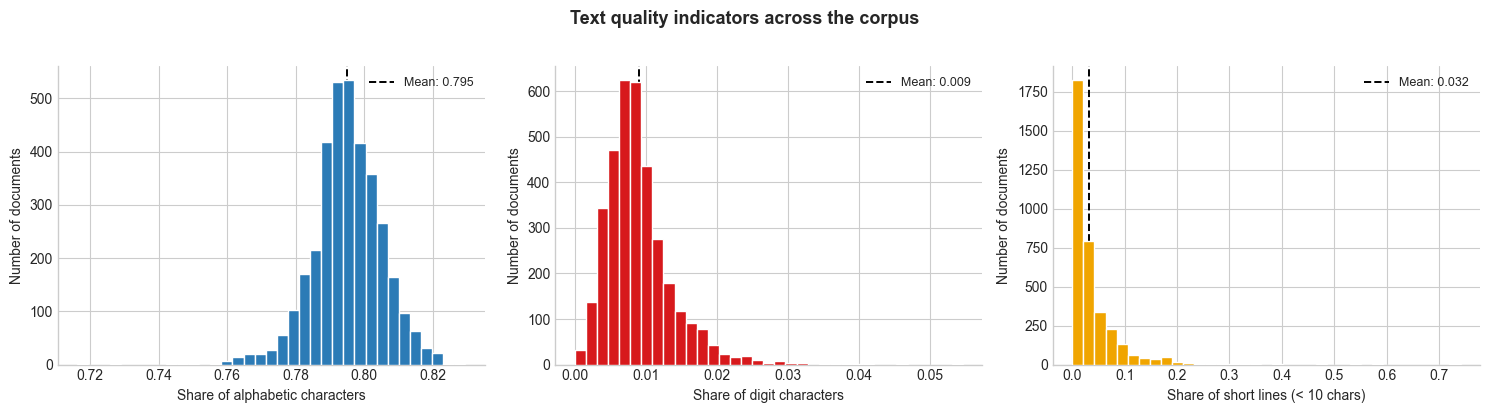

,Metric,Value
0,Mean alphabetic character ratio,0.7951
1,Mean digit ratio,0.0090
2,Mean short-line ratio,0.0317
3,Documents with potential OCR noise,0.0000


In [25]:
# Text quality indicators across the corpus

def alpha_ratio(text):
    letters = sum(c.isalpha() for c in text)
    return letters / len(text) if len(text) > 0 else 0

def digit_ratio(text):
    digits = sum(c.isdigit() for c in text)
    return digits / len(text) if len(text) > 0 else 0

def short_line_ratio(text, threshold=10):
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    if not lines:
        return 0
    return sum(1 for l in lines if len(l) < threshold) / len(lines)

corpus_df['alpha_ratio']      = corpus_df['text'].apply(alpha_ratio)
corpus_df['digit_ratio']      = corpus_df['text'].apply(digit_ratio)
corpus_df['short_line_ratio'] = corpus_df['text'].apply(short_line_ratio)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('alpha_ratio',      'Share of alphabetic characters', '#2C7BB6'),
    ('digit_ratio',      'Share of digit characters',      '#D7191C'),
    ('short_line_ratio', 'Share of short lines (< 10 chars)', '#F0A500'),
]

for ax, (col, label, color) in zip(axes, metrics):
    ax.hist(corpus_df[col], bins=35, color=color, edgecolor='white', zorder=3)
    ax.axvline(corpus_df[col].mean(), color='black', linestyle='--', linewidth=1.4,
               label=f'Mean: {corpus_df[col].mean():.3f}')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Number of documents', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Text quality indicators across the corpus', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

low_quality = corpus_df[
    (corpus_df['alpha_ratio'] < 0.6) | (corpus_df['digit_ratio'] > 0.15)
].shape[0]

quality_summary = pd.DataFrame({
    'Metric': [
        'Mean alphabetic character ratio',
        'Mean digit ratio',
        'Mean short-line ratio',
        'Documents with potential OCR noise'
    ],
    'Value': [
        round(corpus_df['alpha_ratio'].mean(), 4),
        round(corpus_df['digit_ratio'].mean(), 4),
        round(corpus_df['short_line_ratio'].mean(), 4),
        low_quality
    ]
})
quality_summary

A high mean alphabetic ratio, above 0.80, would indicate that the texts are generally clean and that OCR noise is limited. A high digit ratio or a large number of flagged documents would call for an additional preprocessing step before embedding, such as removing isolated numbers or filtering lines that consist almost entirely of non-alphabetic characters. Even a small amount of OCR noise can affect embedding quality, since the model treats garbled strings as unknown tokens that carry no semantic signal.

## 3. Prepare documents for the RAG pipeline

In [26]:
# Wrap each raw text into a LangChain Document
docs = [
    Document(
        page_content=text,
        metadata={"source": file_name}
    )
    for text, file_name in zip(documents, file_names)
]

len(docs)

3628

In [27]:
# Chunk the documents
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(docs)

print(f"Number of chunks: {len(chunks)}")
print()
print("Example of chunk metadata:")
print(chunks[0].metadata if chunks else "No chunk created")


Number of chunks: 16815

Example of chunk metadata:
{'source': 'EL174_L_1988_06_001_01_1_PF_01.txt'}


## 4. Build embeddings and the vector database

In [28]:
# Embedding model
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\nouts\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\nouts\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [29]:
# Create the FAISS vector database
faiss_db = FAISS.from_documents(chunks, embedding_model)

## 5. Build the retrieval system

In [30]:
def retrieve_docs(query, k=5):
    retrieved = faiss_db.similarity_search(query, k=k)

    results = []
    for doc in retrieved:
        results.append({
            "chunk": doc.page_content,
            "metadata": doc.metadata
        })

    return results


In [31]:
# Test retrieval
query = "Quel est le parti dominant en France ?"
retrieved_docs = retrieve_docs(query, k=3)
retrieved_docs


[{'chunk': "Ainsi, pour la région comme pour la France, le choix du 5 juin c'est\nYvette ROUDY et\nPhilippe VACHER\nimp. le brun, caen. 31 74 48 52 ☐ ☒",
  'metadata': {'source': 'EL174_L_1988_06_014_03_1_PF_03.txt'}},
 {'chunk': '· Parce que la Majorité Présidentielle pour la France Unie a besoin de lui.\nDès le premier tour, le 5 juin\nVotez pour la France Unie\nVotez Guy VAXELAIRE\nVU LE CANDIDAT\nImp. du Capucin - Charmes ☒ ☒ ☒',
  'metadata': {'source': 'EL177_L_1988_06_088_03_1_PF_05.txt'}},
 {'chunk': "Ainsi, pour la région comme pour la France, le choix du 12 juin c'est\nYvette ROUDY et Philippe VACHER\nimp. le brun. caen, 31.74 48 52 ☐ ☐ ☐ ☐",
  'metadata': {'source': 'EL174_L_1988_06_014_03_2_PF_01.txt'}}]

In [50]:
# Read the Hugging Face token from the environment
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

if hf_token is None:
    print("No Hugging Face token found in the environment.")
    print("Set HUGGINGFACEHUB_API_TOKEN before running the generation cells.")
else:
    print("Hugging Face token detected.")

Hugging Face token detected.


In [51]:
# Load the LLM
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    huggingfacehub_api_token=hf_token
)

chat_model = ChatHuggingFace(llm=llm)


## 7. Build the RAG system

In [52]:
def ask_llm_with_context(query, context):
    messages = [
        SystemMessage(
            content=(
                "Tu es un journaliste politique spécialisé dans les élections législatives françaises de 1988. "
                "Tu dois répondre de manière factuelle et rigoureuse uniquement à partir du contexte fourni, "
                "qui est constitué de manifestes électoraux de cette période. "
                "Tu n'inventes jamais d'information. "
                "Si la réponse ne se trouve pas dans le contexte, tu dois dire clairement que tu ne sais pas."
            )
        ),
        HumanMessage(
            content=f"""
Question: {query}

Contexte:
{context}

Rédige une réponse courte, factuelle et strictement fondée sur ce contexte.
"""
        )
    ]

    response = chat_model.invoke(messages)
    return response.content


In [53]:
def ask_rag(query, k=5, display_answer=True):
    retrieved = retrieve_docs(query, k=k)

    context = "\n\n".join(
        [f"Source: {item['metadata'].get('source', 'unknown')}\n{item['chunk']}" for item in retrieved]
    )

    answer = ask_llm_with_context(query, context)

    if display_answer:
        display(Markdown(answer))

    return {
        "query": query,
        "retrieved_documents": retrieved,
        "context": context,
        "answer": answer
    }


In [58]:
# Test the full RAG system
query = "Que disent les manifestes sur l'Europe ?"
result = ask_rag(query, k=5)

Selon les manifestes électoraux disponibles, les principaux partis donnent la suivante parole d'ordre sur l'Europe :

- Le candidat Pierre MONTASTRUC est "attache au désenclavement du Sud du Département et à son ouverture à l'EUROPE". 
- Le candidat Hults souhaite "RÉUSSIR LA FRANCE UNIE" et aucun autre propos sur l'Europe n'est mentionné.
-  Le candidat Philippe MERCANTE se prononce contre la politique dite de « l'Europe de 92 » car elle « signifie la régression sociale et démocratique sur toute la ligne, la foire aux capitaux, le surarmement accéléré, le déclin national ».

In [59]:
# Example of a question outside the corpus scope
query = "Qui est Emmanuel Macron ?"
result_out_of_scope = ask_rag(query, k=5)

Je ne peux pas fournir d'informations sur Emmanuel Macron car il ne figure pas dans les manifestes électoraux fournies comme contexte.

In [60]:
# Mini-évaluation RAG vs LLM seul

questions = [
    "Que disent les programmes électoraux de 1988 au sujet du chômage en France selon les documents sur les manifestes politiques français de 1988?",
    "Comment aborde-t-on la question de l'éducation en 1988 en France selon les documents sur les manifestes politiques français de 1988?",
    "Que dit-on de la France en 1988 selon les documents sur les manifestes politiques français de 1988?",
    "Qu'en est-il de la politique économique de la France en 1988 selon les documents sur les manifestes politiques français de 1988?",
    "Comment aborde-t-on la question de l'immigration en France en 1988 selon les documents sur les manifestes politiques français de 1988 ?"
]

rag_answers = []
llm_answers = []
contexts = []

for q in questions:
    # Réponse avec RAG
    rag_result = ask_rag(q, k=5, display_answer=False)
    rag_answers.append(rag_result["answer"])
    contexts.append(rag_result["context"])

    # Réponse sans RAG
    messages = [
        SystemMessage(
            content="Tu es un assistant spécialisé dans l'analyse de textes politiques français."
        ),
        HumanMessage(
            content=f"Réponds à la question suivante : {q}"
        )
    ]

    llm_response = chat_model.invoke(messages)
    llm_answers.append(llm_response.content)


df_eval = pd.DataFrame({
    "question": questions,
    "rag_answer": rag_answers,
    "llm_answer": llm_answers,
    "context": contexts
})


# Métrique simple : part des mots de la réponse présents dans le contexte récupéré

rag_scores = []
llm_scores = []

for i in range(len(df_eval)):
    context_words = set(clean_and_tokenize(df_eval.loc[i, "context"]))

    rag_words = set(clean_and_tokenize(df_eval.loc[i, "rag_answer"]))
    llm_words = set(clean_and_tokenize(df_eval.loc[i, "llm_answer"]))

    rag_score = len(rag_words.intersection(context_words)) / len(rag_words) if len(rag_words) > 0 else 0
    llm_score = len(llm_words.intersection(context_words)) / len(llm_words) if len(llm_words) > 0 else 0

    rag_scores.append(rag_score)
    llm_scores.append(llm_score)

df_eval["rag_grounded_score"] = rag_scores
df_eval["llm_grounded_score"] = llm_scores

print("Score moyen RAG :", df_eval["rag_grounded_score"].mean())
print("Score moyen LLM seul :", df_eval["llm_grounded_score"].mean())

df_eval[["question", "rag_grounded_score", "llm_grounded_score"]]

Score moyen RAG : 0.5394026696954702
Score moyen LLM seul : 0.2068030549590504


,question,rag_grounded_score,llm_grounded_score
0,Que disent les programmes électoraux de 1988 a...,0.409091,0.185185
1,Comment aborde-t-on la question de l'éducation...,0.617021,0.242105
2,Que dit-on de la France en 1988 selon les docu...,0.660000,0.195402
3,Qu'en est-il de la politique économique de la ...,0.604651,0.202020
4,Comment aborde-t-on la question de l'immigrati...,0.406250,0.209302
